<a href="https://colab.research.google.com/github/scelliot-cpu/Elliott_DSPN_26/blob/master/ExerciseSubmissions/16_selecting-the-best-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [ ]:
set.seed(15)

n <- 100
X <- rnorm(n)
epsilon <- rnorm(n)

beta0 <- 2
beta1 <- 1
beta2 <- -1
beta3 <- 0.5

Y <- beta0 + beta1*X + beta2*X^2 + beta3*X^3 + epsilon

data <- data.frame(Y,X)

b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [4]:
install.packages("leaps")
library(leaps)

data$X2 <- data$X^2
data$X3 <- data$X^3
data$X4 <- data$X^4
data$X5 <- data$X^5
data$X6 <- data$X^6
data$X7 <- data$X^7
data$X8 <- data$X^8
data$X9 <- data$X^9
data$X10 <- data$X^10

regfit <- regsubsets(Y ~ X + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10,
                     data, nvmax = 10)

regsummary <- summary(regfit)
print(regsummary)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Subset selection object
Call: regsubsets.formula(Y ~ X + X2 + X3 + X4 + X5 + X6 + X7 + X8 + 
    X9 + X10, data, nvmax = 10)
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  " " "*" "*" " " " " " " " " " " " " " "
3  ( 1 )  "*" "*" "*" " " " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" " " " " "*" " " " " " " " "
5  ( 1 )  "*" "*" "*" " " "*" "*" " " " " " " " "
6  ( 1 )  " " "*" "*" "*" "*" " " "*" " " "*" " "
7  ( 1 )  "*" "*" "*" "*" " " "*" " " "*" " " "*"
8  ( 1 )  "*" "*" "*" "*" "*" "*" " " "*" " " "*"
9  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" "*" "*"
10  ( 

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Based on each criterion, identify the best model size. Report the coefficients of the best model.

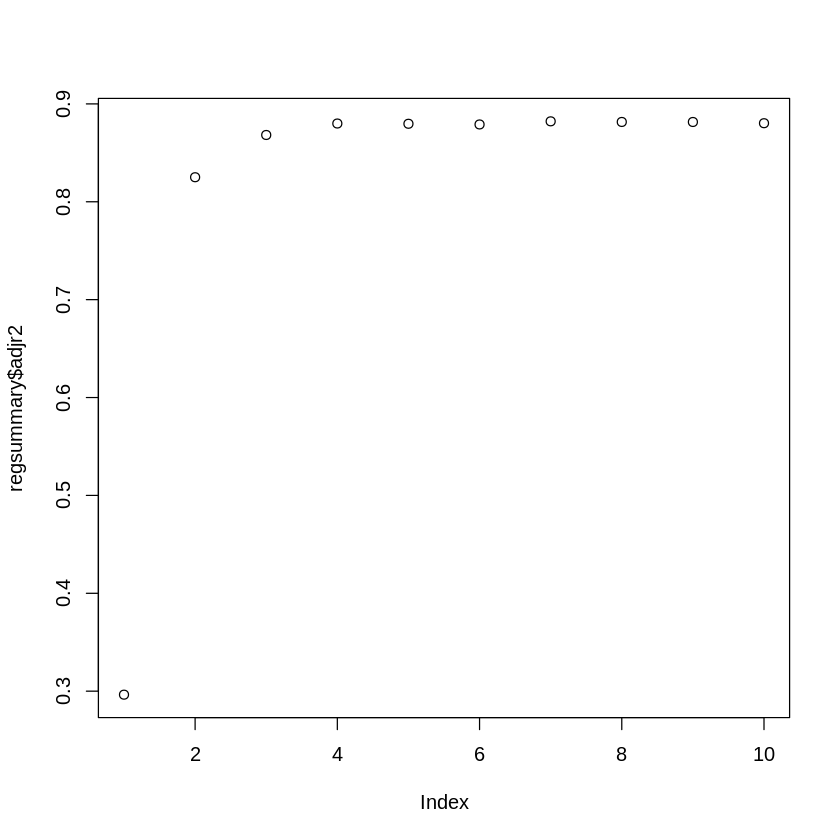

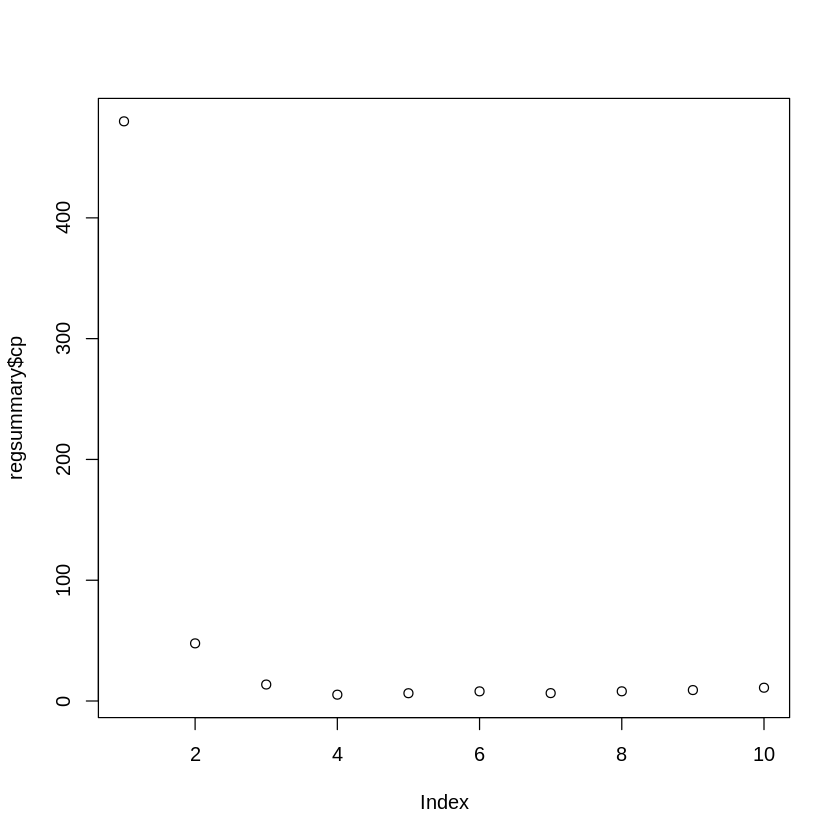

[1] 7

[1] 4

[1] 4

(Intercept)           X          X2          X3          X4          X6 
 1.78997778  1.03229059 -3.68341292  0.49962606  3.40354276 -1.83974566 
         X8         X10 
 0.38471197 -0.02758752

(Intercept)           X          X2          X3          X6 
 1.56961161  1.03196689 -1.49913369  0.49080549 -0.01730072

(Intercept)           X          X2          X3          X6 
 1.56961161  1.03196689 -1.49913369  0.49080549 -0.01730072

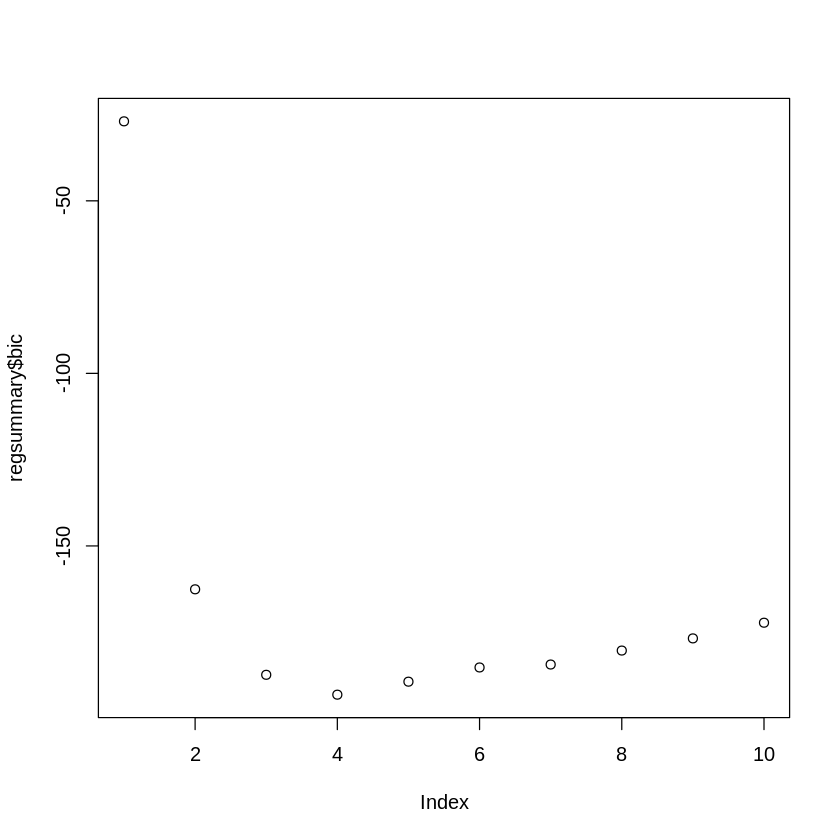

In [5]:
plot(regsummary$adjr2)
plot(regsummary$cp)
plot(regsummary$bic)

which.max(regsummary$adjr2)
which.min(regsummary$cp)
which.min(regsummary$bic)

coef(regfit, which.max(regsummary$adjr2))
coef(regfit, which.min(regsummary$cp))
coef(regfit, which.min(regsummary$bic))

> *For the adjusted R^2 model, the best model had 7 variables, the coefficients for this model were X, X2, X3, X4, X6, X8, and X10. For the Cp model and the BIC model, the best model size was 4 and the coefficients were X, X2, X3, X6.*
>

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to identify the best model under each criterion. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ X + X2 + X3 + X4 + X5 + X6 + X7 + X8 + 
    X9 + X10, data = data, nvmax = 10, method = "forward")
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: forward
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" "*" " " " " " " " " " " " " " " " "
3  ( 1 )  "*" "*" "*" " " " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" " " " " "*" " " " " " " " "
5  ( 1 )  "*" "*" "*" " " "*" "*" " " " " " " " "
6  ( 1 )  "*" "*" "*" " " "*" "*" "*" " " " " " "
7  ( 1 )  "*" "*" "*" " " "*" "*" "*" " " "*" " "
8  ( 1 )  "*" "*" "*" " " "*" "*" "*" "*" "*" " "
9  ( 1 )  "*" "*" "*" "*" "*" "*

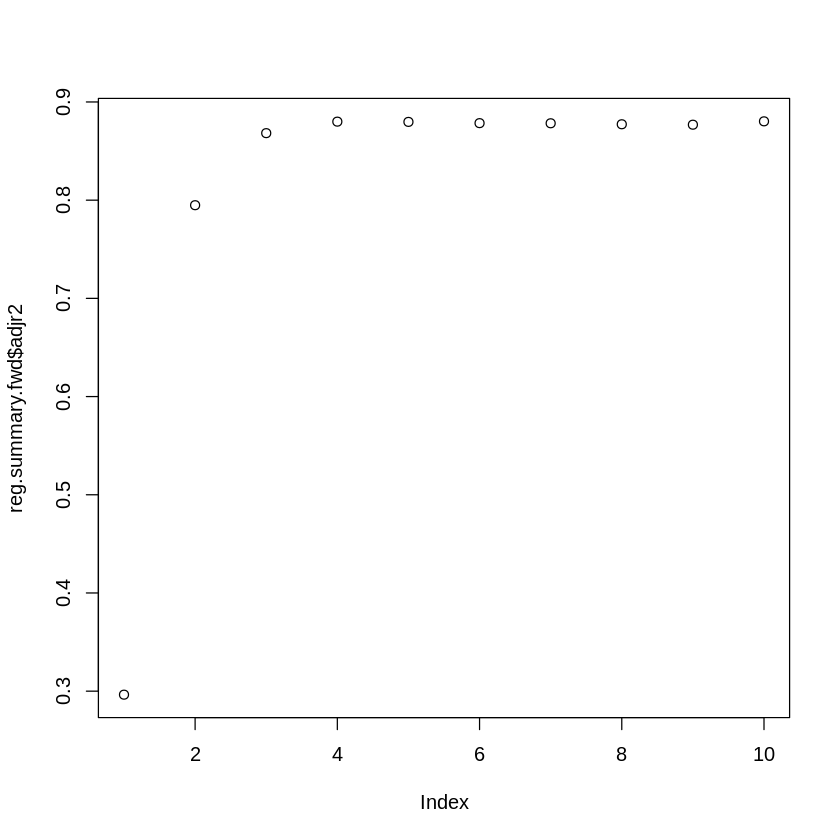

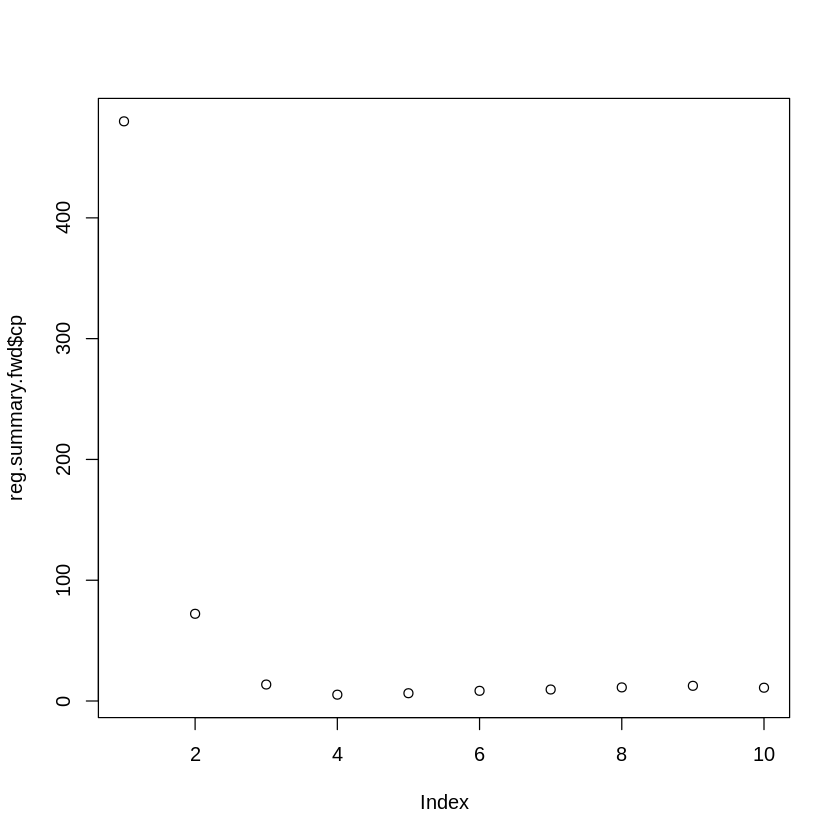

[1] 10

[1] 4

[1] 4

(Intercept)           X          X2          X3          X4          X5 
 1.78609509  0.79059644 -3.84662431  0.40679491  3.94561346  0.43864566 
         X6          X7          X8          X9         X10 
-2.29110020 -0.17943734  0.51414033  0.01839975 -0.03902664

(Intercept)           X          X2          X3          X6 
 1.56961161  1.03196689 -1.49913369  0.49080549 -0.01730072

(Intercept)           X          X2          X3          X6 
 1.56961161  1.03196689 -1.49913369  0.49080549 -0.01730072

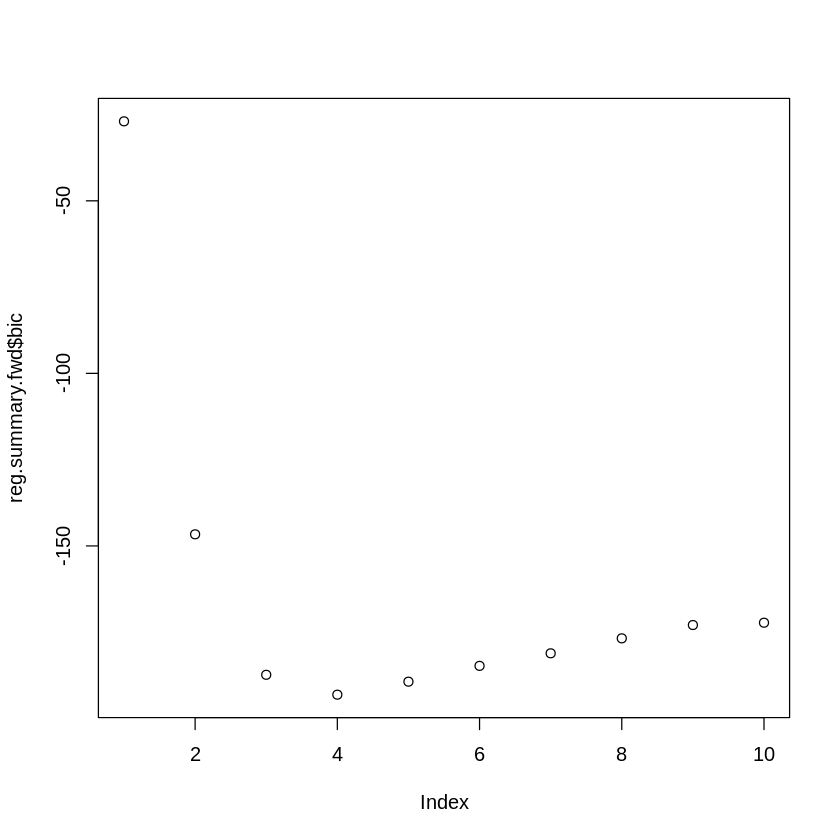

In [6]:
library(leaps)

regfit.fwd <- regsubsets(
  Y ~ X + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10,
  data = data,
  nvmax = 10,
  method = "forward"
)

summary(regfit.fwd)

reg.summary.fwd <- summary(regfit.fwd)

plot(reg.summary.fwd$adjr2)
plot(reg.summary.fwd$cp)
plot(reg.summary.fwd$bic)

which.max(reg.summary.fwd$adjr2)
which.min(reg.summary.fwd$cp)
which.min(reg.summary.fwd$bic)

coef(regfit.fwd, which.max(reg.summary.fwd$adjr2))
coef(regfit.fwd, which.min(reg.summary.fwd$cp))
coef(regfit.fwd, which.min(reg.summary.fwd$bic))

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

b) Backwards stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ X + X2 + X3 + X4 + X5 + X6 + X7 + X8 + 
    X9 + X10, data = data, nvmax = 10, method = "backward")
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: backward
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" "*" " " " " " " " " " " " " " " " "
3  ( 1 )  "*" "*" " " " " "*" " " " " " " " " " "
4  ( 1 )  "*" "*" " " " " "*" "*" " " " " " " " "
5  ( 1 )  "*" "*" " " " " "*" "*" "*" " " " " " "
6  ( 1 )  "*" "*" " " " " "*" "*" "*" "*" " " " "
7  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" " " " "
8  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" " " "*"
9  ( 1 )  "*" "*" " " "*" "*" 

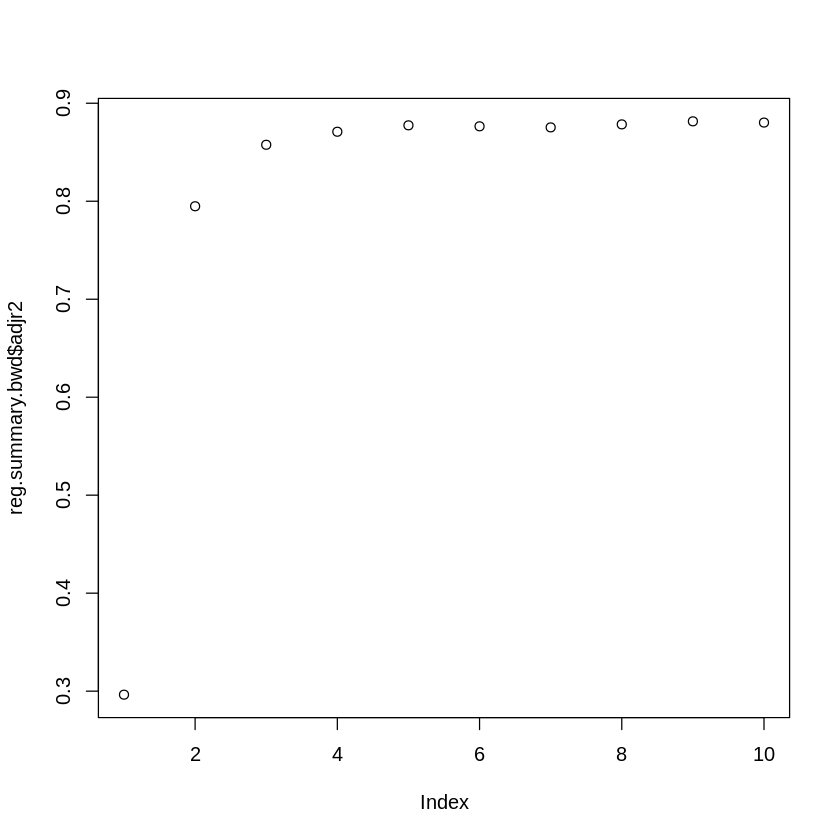

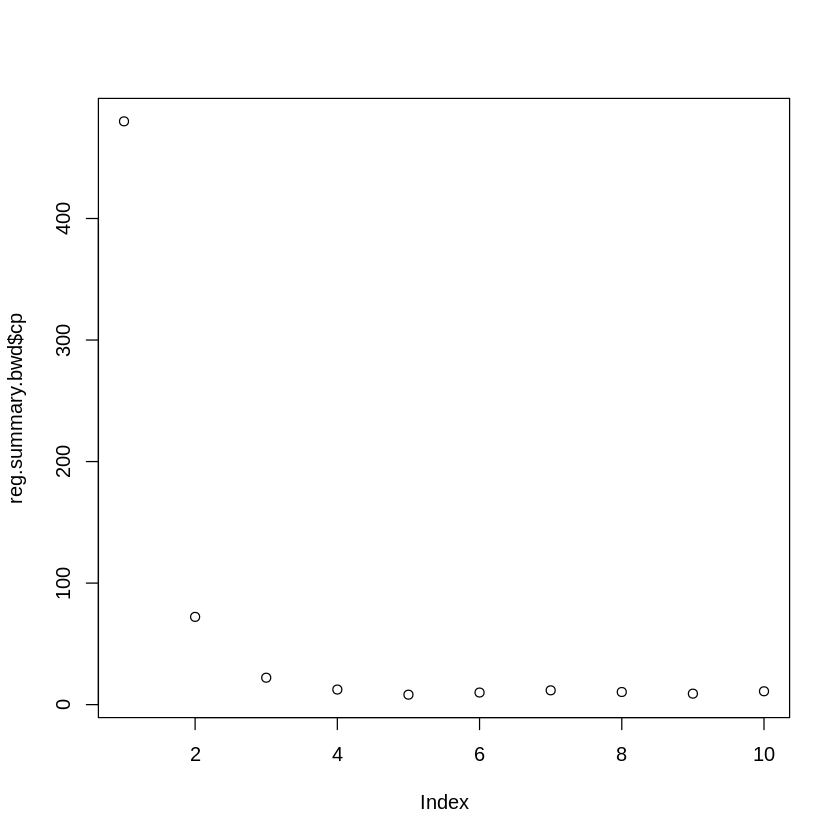

[1] 9

[1] 5

[1] 5

(Intercept)           X          X2          X4          X5          X6 
 1.79373173  0.92635318 -3.91122489  4.10512634  0.75564468 -2.41441373 
         X7          X8          X9         X10 
-0.26614872  0.54831317  0.02584671 -0.04199418

(Intercept)           X          X2          X5          X6          X7 
 1.59814290  1.28224283 -1.54726429  0.22256438 -0.01604063 -0.02528877

(Intercept)           X          X2          X5          X6          X7 
 1.59814290  1.28224283 -1.54726429  0.22256438 -0.01604063 -0.02528877

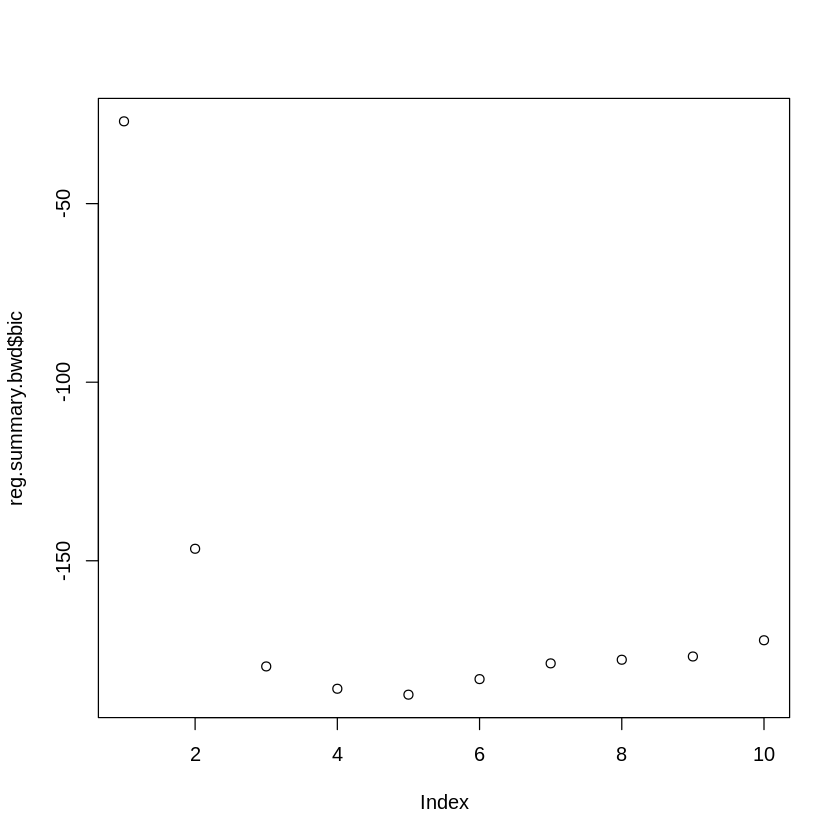

In [7]:
regfit.bwd <- regsubsets(
  Y ~ X + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10,
  data = data,
  nvmax = 10,
  method = "backward"
)

summary(regfit.bwd)

reg.summary.bwd <- summary(regfit.bwd)

plot(reg.summary.bwd$adjr2)
plot(reg.summary.bwd$cp)
plot(reg.summary.bwd$bic)

which.max(reg.summary.bwd$adjr2)
which.min(reg.summary.bwd$cp)
which.min(reg.summary.bwd$bic)

coef(regfit.bwd, which.max(reg.summary.bwd$adjr2))
coef(regfit.bwd, which.min(reg.summary.bwd$cp))
coef(regfit.bwd, which.min(reg.summary.bwd$bic))

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Compare your results from parts a and b with those of question 1. Did the two methods select similar model sizes and predictors? If not, how did they differ?

> *The forward stepwise method produced a different model size for the adjusted R^2, which was 10, however it produced the same model size and coefficients for Cp and BIC. The backwards stepwise method produced different results with adjusted R^2 having a best model size 9, with the coefficients X, X1, X2, X4, X5, X6, X7, X8, X9, and X10. The Cp and BIC models had a best model size of 5, with coefficients X, X2, X5, X6, and X7.*
>

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [8]:
set.seed(1)

n <- 1000
p <- 20

X <- matrix(rnorm(n*p), n, p)
beta <- c(runif(5), rep(0, 15))
eps <- rnorm(n)

Y <- X %*% beta + eps

data <- data.frame(Y, X)

train <- sample(1:n, 100)

train_data <- data[train, ]
test_data <- data[-train, ]

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

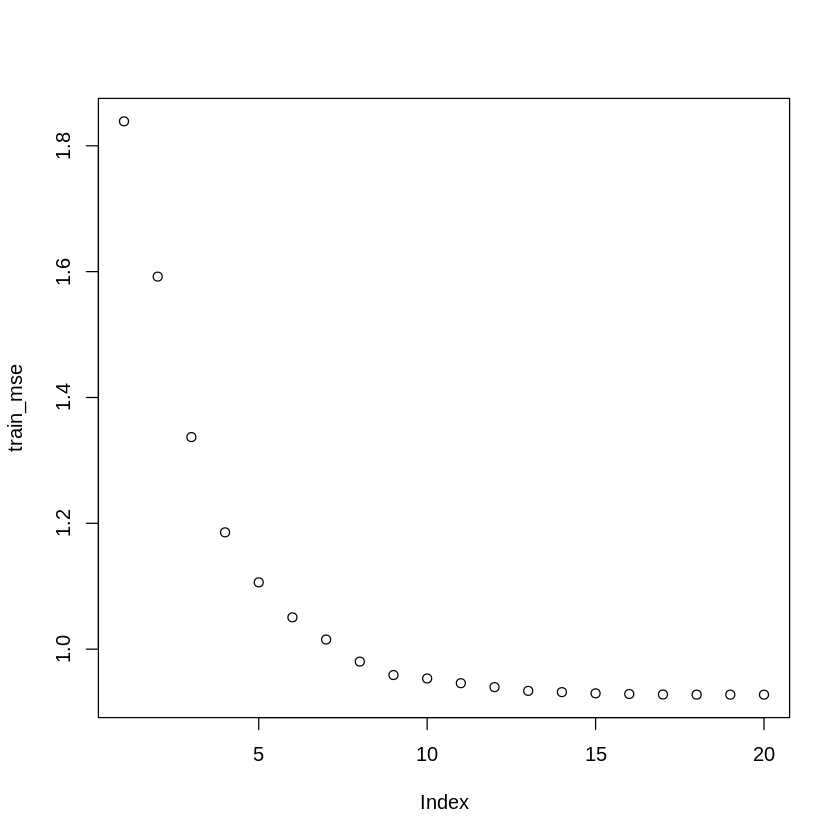

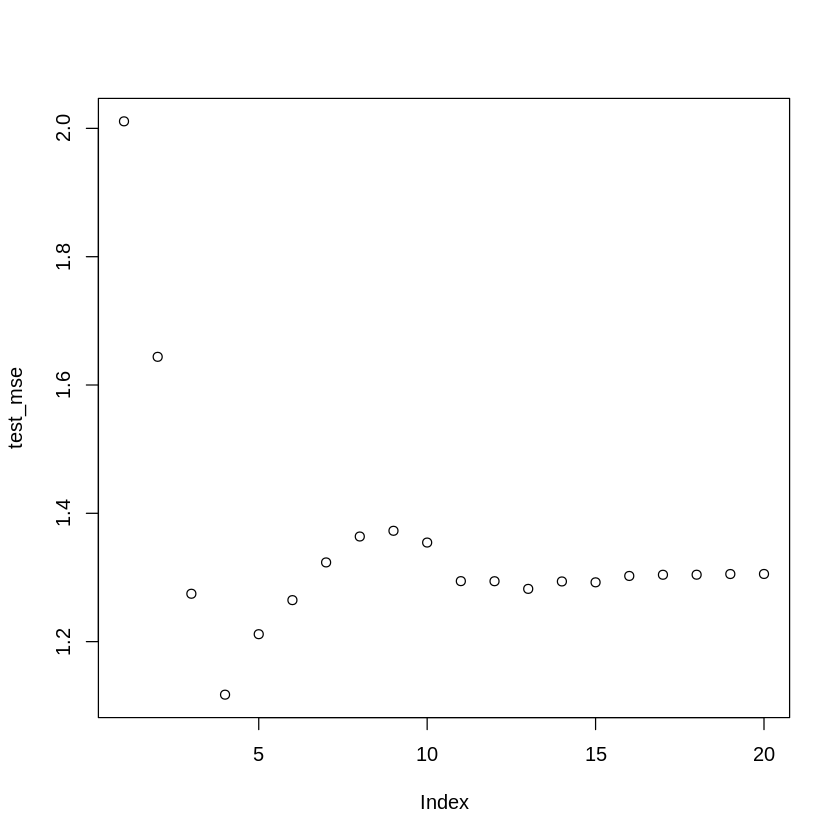

In [9]:
library(leaps)

regfit <- regsubsets(Y ~ ., data = train_data, nvmax = 20)

train_mat <- model.matrix(Y ~ ., train_data)
test_mat <- model.matrix(Y ~ ., test_data)

train_mse <- rep(NA, 20)
test_mse <- rep(NA, 20)

for (i in 1:20) {
  coefi <- coef(regfit, id = i)

  pred_train <- train_mat[, names(coefi)] %*% coefi
  pred_test <- test_mat[, names(coefi)] %*% coefi

  train_mse[i] <- mean((train_data$Y - pred_train)^2)
  test_mse[i] <- mean((test_data$Y - pred_test)^2)
}

plot(train_mse)
plot(test_mse)

c) Identify the best model according to the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [10]:
which.min(test_mse)
coef(regfit, which.min(test_mse))
beta <- c(runif(5), rep(0, 15))

[1] 4

(Intercept)          X1          X2          X3          X4 
 0.06304488  0.66449126  0.53864522  0.53532435  0.35452918

> *The best model size according to the test MSE is 4, this includes the coefficients X1, X2, X3, X4. So in the model that i used to simulate, I included the first 5 variables, so it is close to this, but missing X5.*
>

**DUE:** 11:59pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*